In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
DATA_PATH = Path("../data/diabetes.csv")

df = pd.read_csv(DATA_PATH)

df = df.drop(columns=["Unnamed: 0"])

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [3]:
columns_with_missing_values = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns_with_missing_values] = df[
    columns_with_missing_values
].replace(0, np.nan)

imputer = SimpleImputer(strategy="median")

df[columns_with_missing_values] = imputer.fit_transform(
    df[columns_with_missing_values]
)

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [4]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=df.columns
)

scaled_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


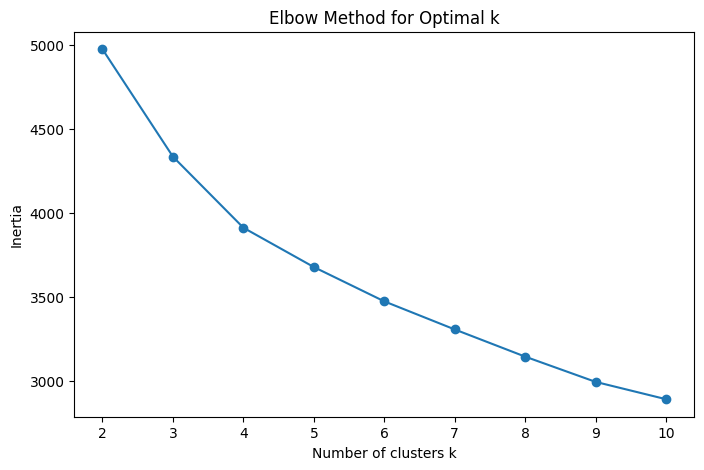

In [5]:
inertias = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")

plt.show()

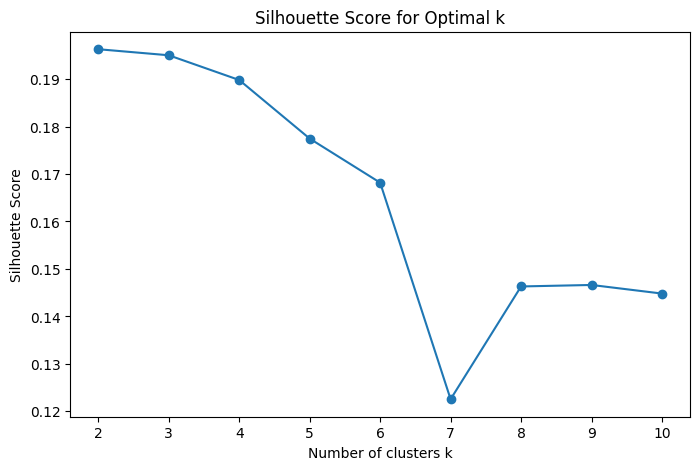

In [6]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(scaled_df)

    score = silhouette_score(scaled_df, cluster_labels)

    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")

plt.show()

In [7]:
k_evaluation_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

k_evaluation_df

,k,Inertia,Silhouette Score
0,2,4975.017186,0.196279
1,3,4335.742198,0.195004
2,4,3912.696235,0.189791
3,5,3678.674745,0.177453
4,6,3474.502594,0.168170
5,7,3307.306732,0.122561
6,8,3145.458522,0.146312
7,9,2995.159219,0.146626
8,10,2892.032609,0.144814


In [8]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)

clusters

array([2, 1, 2, 1, 0, 1, 1, 2, 3, 2, 0, 2, 2, 3, 2, 1, 0, 2, 0, 0, 0, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 2, 0, 1, 1, 2, 1, 2, 2, 0, 0, 1, 2, 2, 2,
       2, 0, 1, 1, 0, 1, 1, 1, 1, 2, 3, 1, 3, 0, 0, 0, 1, 2, 1, 1, 2, 1,
       0, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 0, 0, 1, 1, 1, 2, 1, 0, 1, 2, 1,
       2, 1, 1, 1, 0, 2, 1, 2, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 3, 1, 1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 1, 0, 0, 1, 0, 2, 1, 2,
       0, 2, 1, 1, 1, 1, 0, 3, 2, 2, 1, 2, 3, 1, 2, 0, 2, 1, 0, 1, 2, 3,
       2, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 2, 1, 1, 1, 1, 2, 1, 1, 0, 1, 2,
       2, 0, 2, 0, 1, 1, 1, 1, 2, 2, 3, 0, 2, 0, 1, 2, 2, 2, 1, 0, 1, 1,
       0, 3, 1, 0, 1, 1, 2, 1, 2, 2, 1, 2, 1, 0, 2, 0, 2, 2, 0, 1, 1, 2,
       3, 2, 2, 2, 1, 1, 0, 0, 3, 0, 0, 3, 1, 1, 1, 0, 2, 0, 2, 1, 1, 1,
       1, 1, 0, 2, 2, 3, 3, 1, 2, 1, 1, 1, 2, 0, 1, 1, 3, 2, 1, 1, 1, 2,
       1, 2, 0, 0, 1, 1, 2, 1, 1, 0, 2, 0, 1, 1, 2, 1, 0, 2, 2, 2, 2, 2,
       3, 0, 1, 0, 0, 0, 0, 0, 2, 0, 3, 0, 2, 2, 0,

In [10]:
df["Cluster"] = clusters

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,2
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,1
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,2
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,0


In [11]:
df["Cluster"].value_counts()

Cluster
1    309
2    233
0    184
3     42
Name: count, dtype: int64

In [12]:
cluster_analysis = df.groupby("Cluster").mean()

cluster_analysis

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,1.885870,124.543478,74.494565,36.755435,131.820652,39.209783,0.547500,28.804348
1,2.355987,106.834951,66.734628,23.576052,112.546926,27.892233,0.418006,26.106796
2,7.454936,131.738197,78.450644,29.733906,134.124464,32.539485,0.462506,46.334764
3,3.357143,162.119048,71.095238,32.833333,422.690476,35.966667,0.588881,32.523810


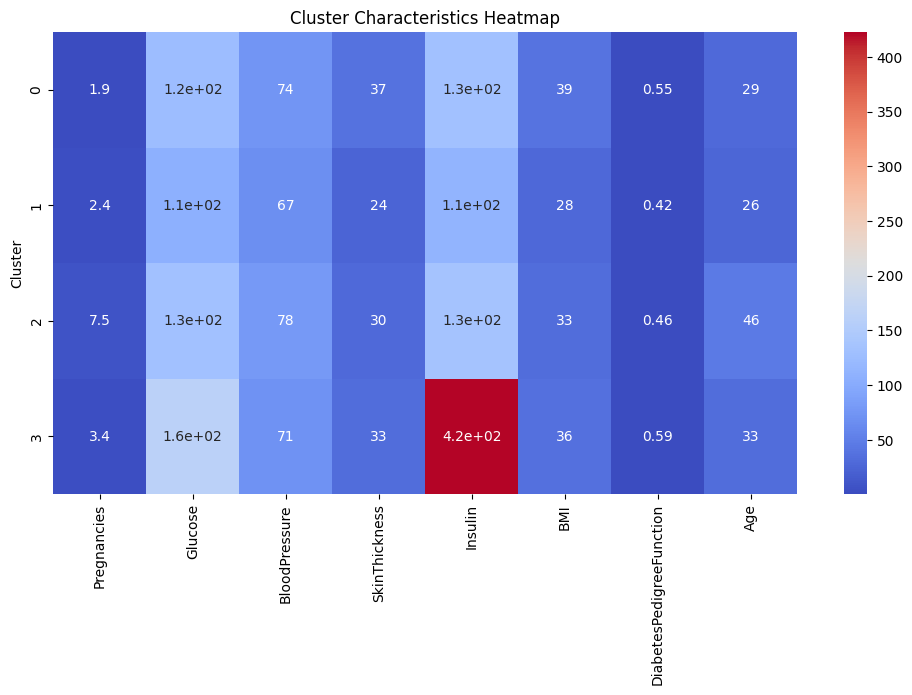

In [13]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_analysis,
    annot=True,
    cmap="coolwarm"
)

plt.title("Cluster Characteristics Heatmap")

plt.show()

In [14]:
from sklearn.decomposition import PCA

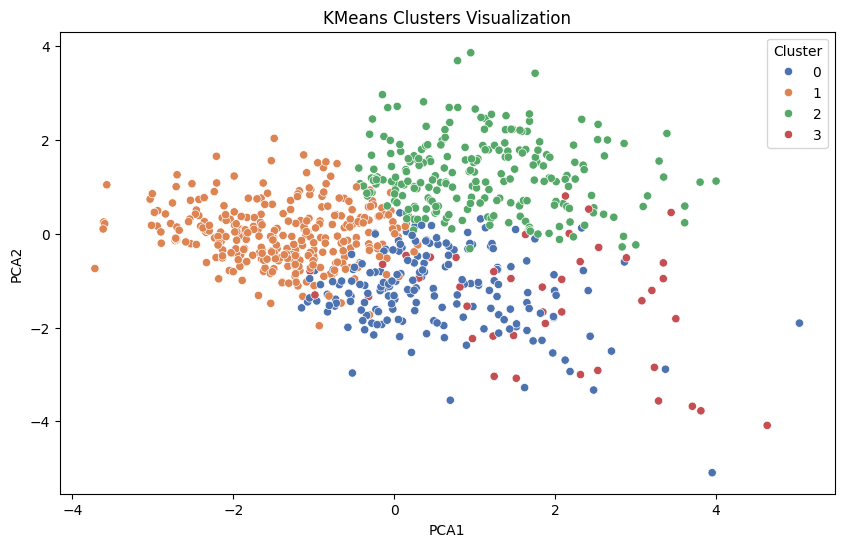

In [15]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_components,
    columns=["PCA1", "PCA2"]
)

pca_df["Cluster"] = clusters

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="deep"
)

plt.title("KMeans Clusters Visualization")

plt.show()